## Gold vs BTC from Apr 2024 till Feb 2026 Analysis

First we need data import

In [288]:
import pandas as pd
import requests as r
import io # workaround for pandas

def import_csv_from_github(uri: str) -> pd.DataFrame:
    csv = r.get(uri).text
    csv = io.StringIO(csv)
    return pd.read_csv(csv, delimiter=',')

btc = import_csv_from_github("https://raw.githubusercontent.com/zkud/gold-vs-btc-2024-2026-analysis/refs/heads/main/data/btc.csv")
gold = import_csv_from_github("https://raw.githubusercontent.com/zkud/gold-vs-btc-2024-2026-analysis/refs/heads/main/data/gold.csv")

In [289]:
ANALYSIS_START = '2024-04'
ANALYSIS_END = '2026-02'

Then we need to aggregate/filter btc and gold data to start from Apr 2026 and end on Feb 2026, to be in monthly AVG.

In [290]:
btc = btc.filter(items=['Open time', 'High', 'Low'])

btc['Month'] = pd.to_datetime(btc['Open time'])
btc['Month'] = btc['Month'].dt.strftime('%Y-%m')
btc = btc[(btc['Month'] <= ANALYSIS_END) & (btc['Month'] >= ANALYSIS_START)]

btc['BTC Price'] = btc['High'].add(btc['Low']).divide(2)

btc = btc.filter(items=['Month', 'BTC Price']).groupby('Month').mean()

btc

,BTC Price
Month,
2024-04,65911.618167
2024-05,65103.576559
2024-06,66027.849972
2024-07,62709.487823
2024-08,60019.138898
2024-09,60170.625111
2024-10,65568.735511
2024-11,86230.337000
2024-12,98301.735027


In [291]:
gold['Month'] = pd.to_datetime(gold['Date'])
gold['Month'] = gold['Month'].dt.strftime('%Y-%m')
gold = gold[(gold['Month'] <= ANALYSIS_END) & (gold['Month'] >= ANALYSIS_START)]

gold['Gold Price'] = gold['Price']

gold = gold.filter(items=['Month', 'Gold Price'])

gold

,Month,Gold Price
2295,2024-04,2331.45
2296,2024-05,2351.13
2297,2024-06,2326.44
2298,2024-07,2398.20
2299,2024-08,2470.15
2300,2024-09,2570.55
2301,2024-10,2690.08
2302,2024-11,2651.13
2303,2024-12,2648.01
2304,2025-01,2709.69


In [292]:
comparison = gold.join(btc, on='Month')
comparison

,Month,Gold Price,BTC Price
2295,2024-04,2331.45,65911.618167
2296,2024-05,2351.13,65103.576559
2297,2024-06,2326.44,66027.849972
2298,2024-07,2398.20,62709.487823
2299,2024-08,2470.15,60019.138898
2300,2024-09,2570.55,60170.625111
2301,2024-10,2690.08,65568.735511
2302,2024-11,2651.13,86230.337000
2303,2024-12,2648.01,98301.735027
2304,2025-01,2709.69,99970.797769


Now let's calculate correlations

<Axes: xlabel='Month'>

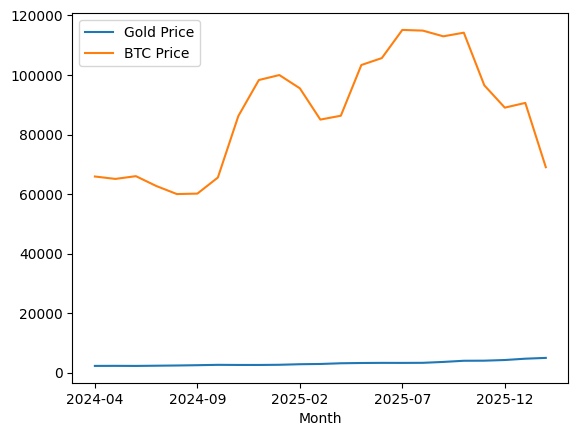

In [293]:
comparison.plot(x = 'Month', y = ['Gold Price', 'BTC Price'])

In [294]:
print(f"Pearson correlation between {ANALYSIS_START} and {ANALYSIS_END} is {comparison['BTC Price'].corr(comparison['Gold Price'])}")

Pearson correlation between 2024-04 and 2026-02 is 0.41493601725359996


In [295]:
print(f"Kendall correlation between {ANALYSIS_START} and {ANALYSIS_END} is {comparison['BTC Price'].corr(comparison['Gold Price'], 'kendall')}")

Kendall correlation between 2024-04 and 2026-02 is 0.391304347826087


In [296]:
print(f"Spearman correlation between {ANALYSIS_START} and {ANALYSIS_END} is {comparison['BTC Price'].corr(comparison['Gold Price'], 'spearman')}")

Spearman correlation between 2024-04 and 2026-02 is 0.608695652173913
